# 测试一个仿真示例并生成截图序列

本 Notebook 会优先尝试运行项目中的雪仿真若干步，并保存截图。
如果当前环境不支持 CUDA 或实时渲染依赖，则回退为从已有仿真视频抽帧生成截图序列。

## 1. 导入必要的库
导入用于仿真与可视化的基础库，以及项目源码路径。

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

# Resolve workspace root robustly for notebook execution contexts
candidates = [Path.cwd(), Path.cwd().parent, Path('/workspaces/SnowSimulation')]
root = None
for c in candidates:
    if (c / 'src').exists():
        root = c
        break
if root is None:
    root = Path('/workspaces/SnowSimulation')

src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

np.random.seed(7)
print(f"Workspace: {root}")
print(f"Source path added: {src_path}")

Workspace: /workspaces/SnowSimulation
Source path added: /workspaces/SnowSimulation/src


## 2. 加载或定义仿真模型
优先尝试构建一个较小规模的 MPM 仿真场景（减少步数和粒子数量，便于快速测试）。

In [2]:
simulation_ready = False
simulation_error = None
solver = None

try:
    import warp as wp
    from simulation.grid import Grid
    from simulation.mpm_solver import MPMSolver
    from simulation.snow_object import SnowObject, create_particle_system

    wp.init()

    # 小规模测试场景，降低资源占用
    grid = Grid(size=64, grid_space=0.015)
    snow_creator = SnowObject(particle_diameter=0.01, target_density=350)

    snowball = snow_creator.create_snowball(
        radius=0.05,
        center=[0.45, 0.9, 0.7],
        velocity=[0.0, 0.0, 0.0],
    )
    snowcube = snow_creator.create_snowcube(
        side_length=0.08,
        center=[0.95, 0.3, 0.75],
        velocity=[0.0, 0.0, 0.0],
    )

    particle_system = create_particle_system([snowball, snowcube])
    solver = MPMSolver(particle_system, grid)
    simulation_ready = True
    print("MPM simulation initialized successfully.")
except Exception as e:
    simulation_error = str(e)
    print("MPM simulation init failed; fallback to video frame extraction.")
    print(simulation_error)

Warp 1.4.2 initialized:
   CUDA Toolkit 12.6, Driver 0.0 (insufficient CUDA driver version!)
   Devices:
     "cpu"      : "x86_64"
   Kernel cache:
     /home/codespace/.cache/warp/1.4.2
Warp UserWarning: 
   Insufficient CUDA driver version.
   The minimum required CUDA driver version is 12.0, but the installed CUDA driver version is 0.0.
   Visit https://github.com/NVIDIA/warp/blob/main/README.md#installing for guidance.
MPM simulation init failed; fallback to video frame extraction.
"cuda" device requested but CUDA is not supported by the hardware or driver


Warp CUDA error: Could not open libcuda.so.
Warp CUDA error: Function cuDriverGetVersion_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function cuda_driver_version, /builds/omniverse/warp/warp/native/warp.cu:1600)
Warp CUDA error: Function cuCtxGetCurrent_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function get_current_context, /builds/omniverse/warp/warp/native/warp.cu:235)
Warp CUDA error: Function cuCtxGetCurrent_f: a suitable driver entry point was not found
Warp CUDA error 36 (in function get_current_context, /builds/omniverse/warp/warp/native/warp.cu:235)


## 3. 运行仿真示例
执行若干时间步，并周期性缓存粒子位置用于后续截图。

In [3]:
snapshots = []
step_indices = []

if simulation_ready:
    try:
        solver.run_initial_step()

        total_steps = 60
        capture_every = 10

        for step in range(total_steps + 1):
            if step % capture_every == 0:
                pos = solver.particle_system.positions.numpy().copy()
                snapshots.append(pos)
                step_indices.append(step)
            solver.run_time_step()

        print(f"Simulation completed: captured {len(snapshots)} snapshots.")
    except Exception as e:
        simulation_ready = False
        simulation_error = str(e)
        snapshots = []
        step_indices = []
        print("Simulation step failed; fallback to video frame extraction.")
        print(simulation_error)
else:
    print("Simulation not available in current environment.")

Simulation not available in current environment.


## 4. 捕获仿真过程中的截图
若仿真运行成功，绘制粒子散点截图；否则从已有视频抽帧生成截图。

In [4]:
output_dir = root / "video_output" / "screenshot_series"
output_dir.mkdir(parents=True, exist_ok=True)

saved_images = []

if snapshots:
    for i, (step, pts) in enumerate(zip(step_indices, snapshots)):
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111)
        ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.7, c=pts[:, 1], cmap="Blues")
        ax.set_xlim(0.0, 1.5)
        ax.set_ylim(0.0, 1.5)
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"MPM Snow Snapshot - step {step}")
        ax.grid(alpha=0.2)

        img_path = output_dir / f"snapshot_{i:02d}_step_{step:03d}.png"
        fig.savefig(img_path, dpi=140, bbox_inches="tight")
        plt.close(fig)
        saved_images.append(img_path)

    print(f"Saved {len(saved_images)} images from live simulation.")
else:
    print("No live simulation snapshots available. Trying video frame extraction...")
    video_path = root / "video_output" / "falling.mp4"

    if not video_path.exists():
        raise FileNotFoundError(f"Video not found: {video_path}")

    try:
        import cv2
    except Exception:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python-headless"])
        import cv2

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Failed to open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        raise RuntimeError("Video has no frames.")

    picks = np.linspace(0, total_frames - 1, 8, dtype=int)

    for i, fidx in enumerate(picks):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fidx))
        ok, frame = cap.read()
        if not ok:
            continue

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_path = output_dir / f"frame_{i:02d}_{fidx:05d}.png"
        plt.imsave(img_path, frame_rgb)
        saved_images.append(img_path)

    cap.release()
    print(f"Saved {len(saved_images)} images from existing simulation video.")

print("Output directory:", output_dir)

No live simulation snapshots available. Trying video frame extraction...
Saved 8 images from existing simulation video.
Output directory: /workspaces/SnowSimulation/video_output/screenshot_series


## 5. 可视化仿真截图序列
将生成的截图按顺序展示。

Total images: 8


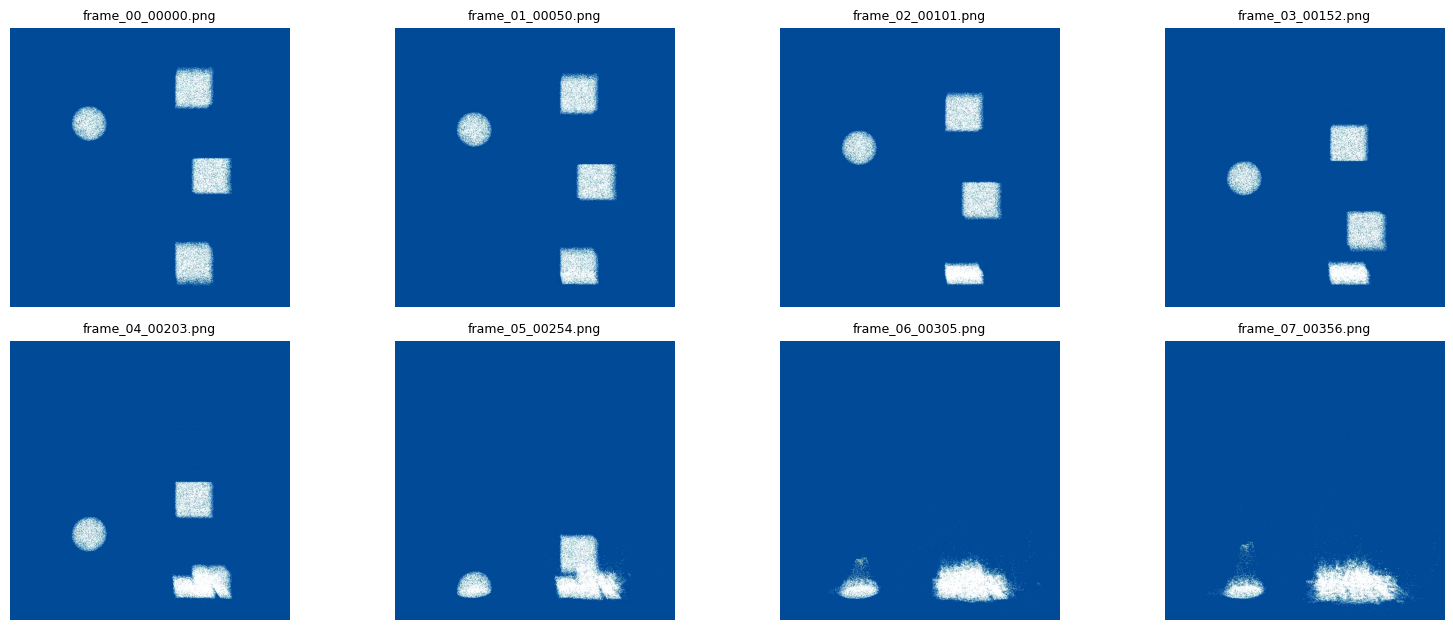

Generated files:
video_output/screenshot_series/frame_00_00000.png
video_output/screenshot_series/frame_01_00050.png
video_output/screenshot_series/frame_02_00101.png
video_output/screenshot_series/frame_03_00152.png
video_output/screenshot_series/frame_04_00203.png
video_output/screenshot_series/frame_05_00254.png
video_output/screenshot_series/frame_06_00305.png
video_output/screenshot_series/frame_07_00356.png


In [5]:
saved_images = sorted(saved_images)
print(f"Total images: {len(saved_images)}")

if not saved_images:
    raise RuntimeError("No images were generated.")

cols = 4
rows = int(np.ceil(len(saved_images) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.2 * rows))
axes = np.array(axes).reshape(-1)

for ax, path in zip(axes, saved_images):
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")

for ax in axes[len(saved_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Generated files:")
for p in saved_images:
    print(p.relative_to(root))